# Stage 1 — Byte Latent Transformer Research README

**Project:** Small Byte Latent Transformer from scratch<br>
**Notebook role:** Research framing, executable concepts, and current-repository audit<br>
**Last refreshed:** August 6, 2026

This notebook is the durable Stage 1 research companion for the project. It explains what a Byte Latent Transformer (BLT) is, distinguishes it from the byte-level GPT currently in this repository, and turns the most important concepts into small executable demonstrations.

> **Scope boundary:** This notebook teaches and inspects BLT mechanics. Its toy patchers and toy entropy model are not reproductions of Meta's trained entropy model or large-scale BLT results.

## Goal

By the end of this notebook, we should be able to answer:

1. What is the difference between tokens, bytes, and latent patches?
2. Why is a byte-level GPT not automatically a BLT?
3. How do fixed, whitespace-like, and entropy-based patch boundaries differ?
4. What are the roles of the local encoder, global latent transformer, and local decoder?
5. What is already implemented in this repository?
6. What must be built before the project can claim a trainable BLT?

## tl;dr

- The repository currently contains a **runnable, forward-only byte-level GPT baseline**.
- It has tensor operations, dense layers, layer normalization, causal multi-head attention, transformer blocks, byte/position embeddings, a 256-byte output head, and greedy generation control flow.
- It does **not** yet have loss calculation, gradients, an optimizer, a dataset pipeline, checkpointing, or learned generation.
- It is **not yet a BLT** because it does not group bytes into patches or contain separate local encoder, global patch transformer, and local decoder modules.
- The next implementation proof remains: make the byte-GPT reproducibly overfit a tiny byte sequence before adding BLT-specific machinery.

## Setup

### Sources

Primary sources used for this research framing:

- [Byte Latent Transformer: Patches Scale Better Than Tokens](https://arxiv.org/html/2412.09871)
- [Official `facebookresearch/blt` repository](https://github.com/facebookresearch/blt)
- [Fast Byte Latent Transformer](https://arxiv.org/abs/2605.08044), treated only as a later extension
- [`PROJECT_ROADMAP.md`](../PROJECT_ROADMAP.md), the implementation-stage reference for this repository

### Environment

The notebook's conceptual examples use Python's standard library and Matplotlib. The repository audit also uses `javac` and `java` when they are available. It compiles Java into a temporary directory and does not modify build artifacts in the repository.

### Key assumptions

- "From scratch" means the architecture and experiment logic are written in this project; the project still needs an explicit decision about whether automatic differentiation should also be built from scratch.
- Tiny local experiments can demonstrate mechanisms and failure modes, but they cannot validate the paper's large-scale efficiency and quality claims.
- Fixed patching should be implemented before entropy patching so architecture bugs and boundary-selection bugs can be isolated.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import math
import platform
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    # Find the repository root whether the kernel starts at root or notebooks/.
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "PROJECT_ROADMAP.md").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate the BLT repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
SOURCE_ROOT = REPO_ROOT / "src" / "main" / "java"

print(f"Python: {platform.python_version()}")
print(f"Repository: {REPO_ROOT}")
print(f"Roadmap present: {(REPO_ROOT / 'PROJECT_ROADMAP.md').exists()}")
print(f"Java source root present: {SOURCE_ROOT.exists()}")

git_result = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
    check=False,
)
print(f"Current Git commit: {git_result.stdout.strip() if git_result.returncode == 0 else 'unavailable'}")

Python: 3.14.6
Repository: /Users/aadikhanna/Github/AI Optimizer/BLT
Roadmap present: True
Java source root present: True
Current Git commit: 9e97791


## Steps

### 1. Start with bytes

A byte-level language model uses a fixed vocabulary of 256 possible values. Text is first encoded into bytes—usually UTF-8—and the model predicts the next byte.

This removes a learned or heuristic subword tokenizer, but it creates longer sequences. A Unicode character may occupy more than one byte, so "character" and "byte" are not interchangeable.

In [2]:
sample_text = "BLT meets café ☕"
sample_bytes = sample_text.encode("utf-8")

print(f"Text: {sample_text!r}")
print(f"Characters: {len(sample_text)}")
print(f"UTF-8 bytes: {len(sample_bytes)}")
print(f"Byte values: {list(sample_bytes)}")
print(f"Hex: {sample_bytes.hex(' ')}")

print("\nIndex | Decimal | Hex  | Single-byte rendering")
print("------|---------|------|----------------------")
for index, value in enumerate(sample_bytes):
    if 32 <= value <= 126:
        rendering = chr(value)
    else:
        rendering = "·"
    print(f"{index:>5} | {value:>7} | 0x{value:02x} | {rendering}")

Text: 'BLT meets café ☕'
Characters: 16
UTF-8 bytes: 19
Byte values: [66, 76, 84, 32, 109, 101, 101, 116, 115, 32, 99, 97, 102, 195, 169, 32, 226, 152, 149]
Hex: 42 4c 54 20 6d 65 65 74 73 20 63 61 66 c3 a9 20 e2 98 95

Index | Decimal | Hex  | Single-byte rendering
------|---------|------|----------------------
    0 |      66 | 0x42 | B
    1 |      76 | 0x4c | L
    2 |      84 | 0x54 | T
    3 |      32 | 0x20 |  
    4 |     109 | 0x6d | m
    5 |     101 | 0x65 | e
    6 |     101 | 0x65 | e
    7 |     116 | 0x74 | t
    8 |     115 | 0x73 | s
    9 |      32 | 0x20 |  
   10 |      99 | 0x63 | c
   11 |      97 | 0x61 | a
   12 |     102 | 0x66 | f
   13 |     195 | 0xc3 | ·
   14 |     169 | 0xa9 | ·
   15 |      32 | 0x20 |  
   16 |     226 | 0xe2 | ·
   17 |     152 | 0x98 | ·
   18 |     149 | 0x95 | ·


**Interpretation:** The byte vocabulary is always small and complete, but UTF-8 expands non-ASCII characters into multiple prediction steps. A conventional byte-GPT pays its full transformer cost at every one of those steps.

### 2. Distinguish tokens from patches

A token is selected from a fixed vocabulary created before model training. A BLT patch is a contextual group of bytes with no fixed patch vocabulary.

| Property | Token | BLT patch |
| --- | --- | --- |
| Unit | Vocabulary item | Group of raw bytes |
| Vocabulary | Fixed and finite | No fixed patch vocabulary |
| Boundary source | Tokenizer rules/statistics | Patching function and current context |
| Direct byte access | Usually hidden after tokenization | Preserved through local byte modules |
| Expensive model step | Once per token | Once per patch |

The next cell implements two intentionally simple patchers. They are useful baselines, not the final BLT patcher.

In [3]:
def fixed_patches(data: bytes, patch_size: int = 4) -> list[bytes]:
    if patch_size <= 0:
        raise ValueError("patch_size must be positive")
    return [data[start : start + patch_size] for start in range(0, len(data), patch_size)]


def whitespace_patches(data: bytes) -> list[bytes]:
    # Simplified educational patcher that ends a patch after ASCII whitespace.
    patches: list[bytes] = []
    patch_start = 0
    for index, value in enumerate(data):
        if chr(value).isspace():
            patches.append(data[patch_start : index + 1])
            patch_start = index + 1
    if patch_start < len(data):
        patches.append(data[patch_start:])
    return [patch for patch in patches if patch]


def visible_patch(patch: bytes) -> str:
    return patch.decode("utf-8", errors="replace").replace(" ", "␠").replace("\n", "↵")


def patch_summary(name: str, data: bytes, patches: list[bytes]) -> dict[str, float | int | str]:
    patch_count = len(patches)
    byte_count = len(data)
    return {
        "strategy": name,
        "bytes": byte_count,
        "patches": patch_count,
        "average_patch_size": byte_count / patch_count if patch_count else 0,
        "global_step_reduction": 1 - (patch_count / byte_count) if byte_count else 0,
        "rendered": " | ".join(visible_patch(patch) for patch in patches),
    }


patch_sample = "BLT allocates compute where bytes become surprising."
patch_bytes = patch_sample.encode("utf-8")

fixed = fixed_patches(patch_bytes, patch_size=4)
whitespace = whitespace_patches(patch_bytes)

summaries = [
    patch_summary("one byte per step", patch_bytes, fixed_patches(patch_bytes, 1)),
    patch_summary("fixed width = 4", patch_bytes, fixed),
    patch_summary("simplified whitespace", patch_bytes, whitespace),
]

for patches in (fixed_patches(patch_bytes, 1), fixed, whitespace):
    assert b"".join(patches) == patch_bytes

for summary in summaries:
    print(f"\n{summary['strategy']}")
    print(f"  bytes: {summary['bytes']}")
    print(f"  patches/global steps: {summary['patches']}")
    print(f"  average patch size: {summary['average_patch_size']:.2f}")
    print(f"  nominal global-step reduction: {summary['global_step_reduction']:.1%}")
    print(f"  {summary['rendered']}")


one byte per step
  bytes: 52
  patches/global steps: 52
  average patch size: 1.00
  nominal global-step reduction: 0.0%
  B | L | T | ␠ | a | l | l | o | c | a | t | e | s | ␠ | c | o | m | p | u | t | e | ␠ | w | h | e | r | e | ␠ | b | y | t | e | s | ␠ | b | e | c | o | m | e | ␠ | s | u | r | p | r | i | s | i | n | g | .

fixed width = 4
  bytes: 52
  patches/global steps: 13
  average patch size: 4.00
  nominal global-step reduction: 75.0%
  BLT␠ | allo | cate | s␠co | mput | e␠wh | ere␠ | byte | s␠be | come | ␠sur | pris | ing.

simplified whitespace
  bytes: 52
  patches/global steps: 7
  average patch size: 7.43
  nominal global-step reduction: 86.5%
  BLT␠ | allocates␠ | compute␠ | where␠ | bytes␠ | become␠ | surprising.


The "global-step reduction" above is only a count of sequence positions presented to a hypothetical global model. It is **not** an end-to-end FLOP or latency measurement: local encoding, decoding, cross-attention, batching, and hardware utilization still have costs.

### 3. Build a toy entropy patcher

The BLT paper uses a small autoregressive byte model to estimate next-byte entropy. High entropy means the next byte is difficult to predict. Patch boundaries allow the large global model to be invoked more frequently around difficult regions and less frequently through predictable regions.

For a next-byte distribution $p(v \mid x_{<i})$ over the 256 byte values, entropy in bits is:

$$
H(x_i) = -\sum_{v=0}^{255} p(v \mid x_{<i}) \log_2 p(v \mid x_{<i})
$$

The following demonstration uses a tiny smoothed byte-bigram model. It is deliberately much smaller and less contextual than the paper's entropy model. Its purpose is to make boundary selection visible.

In [4]:
TOY_CORPUS = (
    "byte models predict the next byte. "
    "byte latent transformers group predictable bytes into patches. "
    "the global model processes patches. "
    "the local model processes bytes. "
    "entropy rises when the continuation is surprising. "
) * 20


def train_bigram_counts(text: str):
    data = text.encode("utf-8")
    transition_counts: dict[int, Counter] = defaultdict(Counter)
    global_counts = Counter(data)
    for previous, current in zip(data, data[1:]):
        transition_counts[previous][current] += 1
    return transition_counts, global_counts


def smoothed_distribution(counts: Counter, alpha: float = 0.01) -> list[float]:
    denominator = sum(counts.values()) + alpha * 256
    return [(counts[value] + alpha) / denominator for value in range(256)]


def entropy_bits(probabilities: list[float]) -> float:
    return -sum(probability * math.log2(probability) for probability in probabilities if probability > 0)


def next_byte_entropies(data: bytes, transition_counts, global_counts) -> list[float]:
    global_distribution = smoothed_distribution(global_counts)
    entropies = [entropy_bits(global_distribution)]
    for index in range(1, len(data)):
        previous = data[index - 1]
        counts = transition_counts.get(previous, global_counts)
        entropies.append(entropy_bits(smoothed_distribution(counts)))
    return entropies


def percentile(values: list[float], fraction: float) -> float:
    ordered = sorted(values)
    index = round((len(ordered) - 1) * fraction)
    return ordered[index]


def entropy_patches(
    data: bytes,
    entropies: list[float],
    threshold: float,
    min_patch_size: int = 2,
    max_patch_size: int = 8,
) -> tuple[list[bytes], list[int]]:
    if len(data) != len(entropies):
        raise ValueError("data and entropies must have equal lengths")
    if not data:
        return [], []

    starts = [0]
    current_start = 0
    for position in range(1, len(data)):
        current_size = position - current_start
        threshold_boundary = entropies[position] >= threshold and current_size >= min_patch_size
        forced_boundary = current_size >= max_patch_size
        if threshold_boundary or forced_boundary:
            starts.append(position)
            current_start = position

    patches = [
        data[start : starts[index + 1] if index + 1 < len(starts) else len(data)]
        for index, start in enumerate(starts)
    ]
    return patches, starts

Threshold: 2.723 bits
Bytes: 55
Patches/global steps: 18
Average patch size: 3.06
Nominal global-step reduction: 67.3%
Patches: byt | e␠ | mo | dels␠ | allo | cat | e␠ | co | mput | e␠ | at | ␠sur | pr | ising␠ | tr | ansit | io | ns.


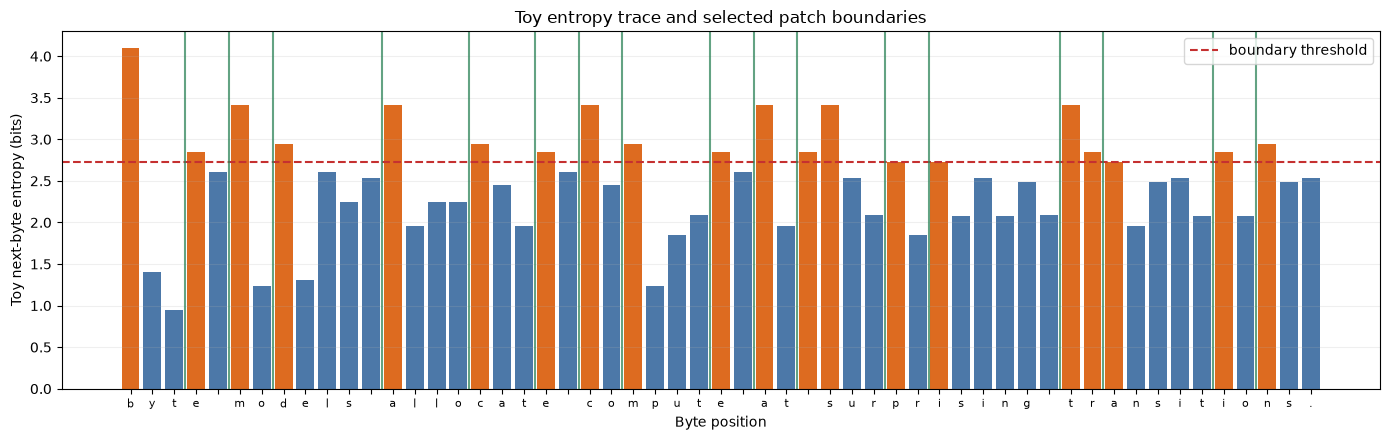

In [5]:
transition_counts, global_counts = train_bigram_counts(TOY_CORPUS)
entropy_sample = "byte models allocate compute at surprising transitions."
entropy_bytes = entropy_sample.encode("utf-8")
entropies = next_byte_entropies(entropy_bytes, transition_counts, global_counts)
entropy_threshold = percentile(entropies[1:], 0.70)
dynamic_patches, patch_starts = entropy_patches(
    entropy_bytes,
    entropies,
    threshold=entropy_threshold,
    min_patch_size=2,
    max_patch_size=8,
)

assert b"".join(dynamic_patches) == entropy_bytes
assert all(1 <= len(patch) <= 8 for patch in dynamic_patches)
assert all(len(patch) >= 2 for patch in dynamic_patches[:-1])

summary = patch_summary("toy entropy", entropy_bytes, dynamic_patches)
print(f"Threshold: {entropy_threshold:.3f} bits")
print(f"Bytes: {summary['bytes']}")
print(f"Patches/global steps: {summary['patches']}")
print(f"Average patch size: {summary['average_patch_size']:.2f}")
print(f"Nominal global-step reduction: {summary['global_step_reduction']:.1%}")
print(f"Patches: {summary['rendered']}")

labels = [chr(value) if 32 <= value <= 126 else "·" for value in entropy_bytes]
positions = list(range(len(entropy_bytes)))

fig, ax = plt.subplots(figsize=(14, 4.5))
colors = ["#dd6b20" if value >= entropy_threshold else "#4c78a8" for value in entropies]
ax.bar(positions, entropies, color=colors, width=0.82)
ax.axhline(entropy_threshold, color="#c53030", linestyle="--", label="boundary threshold")
for start in patch_starts[1:]:
    ax.axvline(start - 0.5, color="#2f855a", alpha=0.75, linewidth=1.5)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Toy next-byte entropy (bits)")
ax.set_xlabel("Byte position")
ax.set_title("Toy entropy trace and selected patch boundaries")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

**How to read the chart:** Orange bars meet or exceed the selected entropy threshold. Green vertical lines show boundaries after minimum/maximum patch-size rules are applied. Because this proxy conditions on only one preceding byte and learns from a tiny repeated corpus, its entropy values and boundaries must not be compared numerically with the paper.

The implementation lesson is the important part: a patcher needs both an uncertainty signal and boundary constraints, and generation-time decisions must depend only on the prefix available so far.

### 4. Map the actual BLT architecture

The original BLT architecture contains three model-scale regions:

```text
raw UTF-8 bytes
      |
      v
+---------------------------+
| Lightweight local encoder |
| - byte embeddings         |
| - optional hash n-grams   |
| - local causal attention  |
| - byte-to-patch pooling   |
+---------------------------+
      |
      v
latent patch representations
      |
      v
+---------------------------+
| Large global transformer  |
| - operates on patches     |
| - block-causal attention  |
| - consumes most compute   |
+---------------------------+
      |
      v
contextual patch representations
      |
      v
+---------------------------+
| Lightweight local decoder |
| - patch-to-byte attention |
| - local causal attention  |
| - predicts 256 byte logits|
+---------------------------+
```

| Module | Input unit | Primary responsibility | Project status |
| --- | --- | --- | --- |
| Patcher | Bytes and prefix context | Assign byte positions to patches | Not implemented |
| Local encoder | Bytes | Create expressive patch representations | Not implemented |
| Global transformer | Patches | Perform expensive contextual reasoning | Not implemented |
| Local decoder | Bytes + global patches | Produce next-byte logits | Not implemented |
| Current Java GPT | Bytes | Run a full transformer at every byte | Forward pass implemented |

#### Cross-attention direction

- **Encoder:** patch representations are queries; byte representations inside the patch are keys and values.
- **Decoder:** byte representations are queries; relevant global patch representations are keys and values.

This reversal is how information is compressed from bytes into patches and then expanded back into byte-level predictions.

### 5. Audit the current repository

The next cells inspect the source tree and perform a clean temporary Java compilation. This keeps the status assessment tied to the code that is actually present when the notebook runs.

In [6]:
source_files = sorted(SOURCE_ROOT.rglob("*.java"))
source_text = "\n".join(path.read_text(encoding="utf-8") for path in source_files)

expected_files = {
    "Tensor": SOURCE_ROOT / "com" / "blt" / "tensor" / "Tensor.java",
    "Linear": SOURCE_ROOT / "com" / "blt" / "nn" / "Linear.java",
    "LayerNorm": SOURCE_ROOT / "com" / "blt" / "nn" / "LayerNorm.java",
    "MultiHeadAttention": SOURCE_ROOT / "com" / "blt" / "transformer" / "MultiHeadAttention.java",
    "Block": SOURCE_ROOT / "com" / "blt" / "transformer" / "Block.java",
    "GPT": SOURCE_ROOT / "com" / "blt" / "transformer" / "GPT.java",
}

print(f"Java source files found: {len(source_files)}")
for component, path in expected_files.items():
    relative = path.relative_to(REPO_ROOT)
    line_count = len(path.read_text(encoding="utf-8").splitlines()) if path.exists() else 0
    print(f"  {component:<20} present={str(path.exists()):<5} lines={line_count:<4} path={relative}")

feature_checks = {
    "matrix multiplication": "matmul(" in source_text,
    "row-wise softmax": "softmax(" in source_text,
    "layer normalization": "class LayerNorm" in source_text,
    "causal attention mask": "source > position" in source_text,
    "transformer block": "class Block" in source_text,
    "byte generation loop": "generateBytes(" in source_text,
    "backward pass": "backward(" in source_text,
    "optimizer implementation": "class Adam" in source_text or "class Optimizer" in source_text,
    "cross-entropy loss": "CrossEntropy" in source_text or "crossEntropy" in source_text,
    "checkpoint implementation": "checkpoint" in source_text.lower(),
    "patcher implementation": "class Patcher" in source_text,
    "local BLT encoder": "class LocalEncoder" in source_text,
    "local BLT decoder": "class LocalDecoder" in source_text,
}

print("\nFeature audit")
for feature, present in feature_checks.items():
    print(f"  {'YES' if present else 'NO ':<3}  {feature}")

Java source files found: 10
  Tensor               present=True  lines=188  path=src/main/java/com/blt/tensor/Tensor.java
  Linear               present=True  lines=42   path=src/main/java/com/blt/nn/Linear.java
  LayerNorm            present=True  lines=58   path=src/main/java/com/blt/nn/LayerNorm.java
  MultiHeadAttention   present=True  lines=106  path=src/main/java/com/blt/transformer/MultiHeadAttention.java
  Block                present=True  lines=58   path=src/main/java/com/blt/transformer/Block.java
  GPT                  present=True  lines=172  path=src/main/java/com/blt/transformer/GPT.java

Feature audit
  YES  matrix multiplication
  YES  row-wise softmax
  YES  layer normalization
  YES  causal attention mask
  YES  transformer block
  YES  byte generation loop
  NO   backward pass
  NO   optimizer implementation
  NO   cross-entropy loss
  NO   checkpoint implementation
  NO   patcher implementation
  NO   local BLT encoder
  NO   local BLT decoder


In [7]:
javac = shutil.which("javac")
java = shutil.which("java")

if not javac or not java:
    print("Java smoke check skipped: javac and/or java is unavailable.")
else:
    with tempfile.TemporaryDirectory(prefix="blt-notebook-build-") as build_directory:
        compile_command = [javac, "-d", build_directory, *map(str, source_files)]
        compile_result = subprocess.run(compile_command, capture_output=True, text=True, check=False)
        print(f"javac exit code: {compile_result.returncode}")
        if compile_result.stdout.strip():
            print(compile_result.stdout.strip())
        if compile_result.stderr.strip():
            print(compile_result.stderr.strip())
        if compile_result.returncode != 0:
            raise RuntimeError("Java compilation failed")

        run_result = subprocess.run(
            [java, "-cp", build_directory, "com.blt.Main"],
            capture_output=True,
            text=True,
            check=False,
        )
        print(f"java exit code: {run_result.returncode}")
        print(run_result.stdout.strip())
        if run_result.stderr.strip():
            print(run_result.stderr.strip())
        if run_result.returncode != 0:
            raise RuntimeError("Java smoke test failed")
        if "GPT logits shape: Tensor(3x256)" not in run_result.stdout:
            raise AssertionError("Expected GPT output shape was not observed")

javac exit code: 0
java exit code: 0
Hello, Byte Latent Transformer!
Matmul Result:
[[19.0, 22.0], [43.0, 50.0]]
Linear output shape: Tensor(2x3)
LayerNorm Result:
[[-0.99998, 0.99998], [-0.99998, 0.99998]]
Attention output shape: Tensor(3x4)
GPT logits shape: Tensor(3x256)
Generated byte count: 7


### Current-state conclusion

The source audit and smoke check support a narrow conclusion:

> The repository has the forward mechanics of a small causal byte-level GPT. It does not yet contain a training system or the patch-based hierarchy that defines BLT.

The label `complete blt` in the earlier commit history should therefore be interpreted as completion of the original forward-pass assignment skeleton, not completion of a trainable research BLT.

### 6. Separate paper claims from project hypotheses

| Topic | Paper-level finding or design | What this project can responsibly test |
| --- | --- | --- |
| Tokenizer-free modeling | BLT learns from raw bytes without a fixed patch vocabulary | Confirm that all project inputs and targets are byte values |
| Dynamic compute | Entropy patching allocates more global steps around difficult predictions | Visualize boundaries and count patch/global positions |
| Scaling | The paper reports favorable controlled scaling at up to billions of parameters | **Cannot be reproduced at tiny local scale** |
| Inference efficiency | Longer patches reduce expensive global transformer steps | Measure step counts, then local wall-clock behavior with caveats |
| Robustness | The paper reports improvements on noise and character-sensitive tasks | Run small controlled corruption tests without generalizing broadly |
| Cross-attention | Local modules move information between byte and patch representations | Verify shapes, masks, causality, and end-to-end learning |

This table is a guardrail: local observations should be reported as local observations, not as confirmation of large-scale paper claims.

## Checks

### Stage 1 exit checklist

- [x] Define byte, token, and latent patch.
- [x] Explain why a byte-level GPT is not automatically a BLT.
- [x] Identify the local encoder, global transformer, and local decoder.
- [x] Explain encoder and decoder cross-attention direction.
- [x] Demonstrate fixed and whitespace-like patching.
- [x] Demonstrate the mechanics of entropy-based boundaries with a clearly labeled toy model.
- [x] Audit the current repository against the target architecture.
- [x] Separate paper claims from locally testable hypotheses.
- [ ] Decide whether the trainable implementation will use custom Java gradients or PyTorch autograd.
- [ ] Add a concise architecture summary and notebook link to the root README.

### Reasonableness checks performed by this notebook

- UTF-8 byte length is shown separately from character length.
- Patch statistics reconcile back to the original byte count.
- Entropy boundaries obey minimum and maximum patch sizes.
- The repository is inspected from disk rather than described only from cached notes.
- Java compilation occurs in a temporary directory.
- The expected `3 x 256` GPT output shape is asserted.

## Next Steps

### Immediate implementation milestone

Make the existing byte-GPT reproducibly learn and overfit one tiny byte sequence.

Recommended order:

1. Add deterministic initialization and automated forward tests.
2. Choose the gradient boundary: custom Java differentiation or PyTorch autograd.
3. Add next-byte cross-entropy loss.
4. Add an optimizer and gradient clipping.
5. Train on one repeated sequence until loss falls sharply.
6. Save and reload a checkpoint with identical logits.
7. Add deterministic temperature and top-k sampling.
8. Build the simple generation/inspection UI.
9. Only then implement fixed patches and the local/global/local BLT hierarchy.

### Why this order matters

If patching is added before the baseline can learn, failures could come from tensor math, gradients, optimization, byte data, causal masks, patch boundaries, cross-attention, or decoding. A trained byte-GPT isolates the lower layers before the BLT hierarchy increases the debugging surface.

## Glossary

| Term | Working definition for this project |
| --- | --- |
| Byte | An integer from 0 to 255; UTF-8 text may use multiple bytes per character |
| Token | An item from a fixed tokenizer vocabulary |
| Patch | A contextual group of bytes mapped to a latent representation without a fixed patch vocabulary |
| Patcher | The function that decides which byte begins each patch |
| Entropy | Uncertainty in a next-byte probability distribution |
| Local encoder | Lightweight byte-level model that creates patch representations |
| Global transformer | Large autoregressive model that processes patch representations |
| Local decoder | Lightweight byte-level model that turns global patch context into byte predictions |
| Cross-attention | Attention where queries come from one representation level and keys/values from another |
| Bits per byte | Byte-language-model loss expressed in base-2 information units |
| Incremental patching | Boundary decisions for a prefix do not depend on future, unseen bytes |

## Research notes and limitations

- The original BLT paper's central claim is about scaling behavior under controlled compute. This notebook does not attempt that reproduction.
- The toy bigram entropy model is intentionally weak. A real BLT entropy model uses substantially richer context.
- Counting patches estimates how often the global model runs, not full system performance.
- A tiny project may expose architectural behavior without showing the quality/efficiency crossover reported at large scale.
- The later Fast BLT work explores generating multiple bytes per expensive model invocation. It should remain out of scope until the original autoregressive BLT is implemented and measured.

## References

1. Pagnoni, A. et al. [*Byte Latent Transformer: Patches Scale Better Than Tokens*](https://arxiv.org/html/2412.09871).
2. Meta Research. [`facebookresearch/blt`](https://github.com/facebookresearch/blt), official research code.
3. Kallini, J. et al. [*Fast Byte Latent Transformer*](https://arxiv.org/abs/2605.08044), optional future research direction.
4. Project implementation plan: [`PROJECT_ROADMAP.md`](../PROJECT_ROADMAP.md).

---

**Stage 1 handoff:** The conceptual boundary is now explicit. The repository currently implements a byte-GPT forward baseline; the next proof is learning, and the later BLT proof is patch-based global computation with local byte encoding and decoding.